# Cluster Insight Analysis - VN30

This notebook is the **cluster diagnostic** and **cluster metadata enrichment** step after `04_corr_cluster.ipynb`.

It is used to:

1. review the cluster structure that already exists
2. compare intra-cluster and inter-cluster correlation patterns
3. characterize each cluster with ticker-level return and volatility metadata
4. export `ticker_clusters_enriched.csv` for downstream optimization

This notebook does not create new clusters.
This notebook does not change `K`.
This notebook does not change `cluster_id`.
This notebook does not optimize portfolios.

**Input files:**

- `return_matrix_clean.csv`
- `corr_matrix.csv`
- `cov_matrix.csv`
- `ticker_clusters.csv`

**Primary output:**

- `ticker_clusters_enriched.csv`

Notebook `06_markowitz_static.ipynb` uses this output directly: `mean_ret` becomes `mu`, and `cluster_id` is used to apply cluster caps.


In [1]:
# Import libraries
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Safe plotting configuration with robust sans-serif fallback
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

print("[OK] Library import and plotting configuration completed")


[OK] Library import and plotting configuration completed


## Step 1: Load inputs and validate the ticker universe

The notebook loads `cov_matrix.csv` even though it does not optimize a portfolio. It is kept here as a **consistency check** so the return matrix, correlation matrix, covariance matrix, and cluster metadata all refer to the same ticker universe before enrichment and handoff to notebook 06.


In [2]:
# Setup paths
import sys

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS_CLUSTER_INSIGHT = PROJECT_ROOT / "reports" / "cluster_insight"
REPORTS_CLUSTER_INSIGHT_FIG = REPORTS_CLUSTER_INSIGHT / "figures"
HELPERS_DIR = PROJECT_ROOT / "notebooks" / "helpers"

if str(HELPERS_DIR) not in sys.path:
    sys.path.insert(0, str(HELPERS_DIR))

from cluster_correlation_diagnostics import build_cluster_correlation_diagnostics

REPORTS_CLUSTER_INSIGHT.mkdir(parents=True, exist_ok=True)
REPORTS_CLUSTER_INSIGHT_FIG.mkdir(parents=True, exist_ok=True)

# Read input files
ret = pd.read_csv(
    DATA_PROCESSED / "return_matrix_clean.csv", index_col=0, parse_dates=True
)
corr_matrix = pd.read_csv(DATA_PROCESSED / "corr_matrix.csv", index_col=0)
cov_matrix = pd.read_csv(DATA_PROCESSED / "cov_matrix.csv", index_col=0)
clusters = pd.read_csv(DATA_PROCESSED / "ticker_clusters.csv")

# Standardize cluster metadata
clusters["ticker"] = clusters["ticker"].astype(str).str.upper().str.strip()
clusters["cluster_id"] = clusters["cluster_id"].astype(int)

print("=" * 60)
print("INPUT VALIDATION - CLUSTER INSIGHT")
print("=" * 60)

assert corr_matrix.shape[0] == corr_matrix.shape[1], "corr_matrix must be square"
assert cov_matrix.shape[0] == cov_matrix.shape[1], "cov_matrix must be square"
assert set(corr_matrix.index) == set(corr_matrix.columns), "corr_matrix index/columns mismatch"
assert set(cov_matrix.index) == set(cov_matrix.columns), "cov_matrix index/columns mismatch"
assert corr_matrix.index.tolist() == corr_matrix.columns.tolist(), (
    "corr_matrix row/column order drifted; notebook 05 requires identical row/column order "
    "before pairwise correlation diagnostics"
)
assert cov_matrix.index.tolist() == cov_matrix.columns.tolist(), (
    "cov_matrix row/column order drifted; notebook 05 requires identical row/column order "
    "before downstream consistency checks"
)

tickers_ret = sorted(ret.columns.tolist())
tickers_corr = sorted(corr_matrix.columns.tolist())
tickers_cov = sorted(cov_matrix.columns.tolist())
tickers_clust = sorted(clusters["ticker"].unique().tolist())

print()
print("1. DataFrame shapes:")
print(f"   - return_matrix: {ret.shape}")
print(f"   - corr_matrix: {corr_matrix.shape}")
print(f"   - cov_matrix: {cov_matrix.shape}")
print(f"   - clusters: {clusters.shape}")

print()
print("2. Number of tickers in each input:")
print(f"   - return_matrix: {len(tickers_ret)}")
print(f"   - corr_matrix: {len(tickers_corr)}")
print(f"   - cov_matrix: {len(tickers_cov)}")
print(f"   - clusters: {len(tickers_clust)}")

assert set(ret.columns) == set(corr_matrix.columns) == set(cov_matrix.columns) == set(clusters["ticker"]), (
    "Ticker universe mismatch between ret/corr/cov/clusters"
)

expected_number_of_tickers = len(tickers_ret)

print()
print("3. Ticker universe check:")
print("   - PASS: all ticker sets match across ret/corr/cov/clusters")

print()
print("4. Why cov_matrix.csv is still loaded:")
print("   - cov_matrix.csv is loaded for downstream consistency validation even though notebook 05 does not optimize portfolios.")

print()
print("5. Preview of cluster assignments:")
print(clusters.head(10))

print()
print("[OK] Input loading and universe validation completed")


INPUT VALIDATION - CLUSTER INSIGHT

1. DataFrame shapes:
   - return_matrix: (1435, 29)
   - corr_matrix: (29, 29)
   - cov_matrix: (29, 29)
   - clusters: (29, 2)

2. Number of tickers in each input:
   - return_matrix: 29
   - corr_matrix: 29
   - cov_matrix: 29
   - clusters: 29

3. Ticker universe check:
   - PASS: all ticker sets match across ret/corr/cov/clusters

4. Why cov_matrix.csv is still loaded:
   - cov_matrix.csv is loaded for downstream consistency validation even though notebook 05 does not optimize portfolios.

5. Preview of cluster assignments:
  ticker  cluster_id
0    ACB           1
1    BID           1
2    CTG           1
3    HDB           1
4    LPB           1
5    MBB           1
6    SHB           1
7    STB           1
8    TCB           1
9    TPB           1

[OK] Input loading and universe validation completed


## Step 2: Cluster overview

This block summarizes the existing cluster allocation only. It does not change the cluster structure. The goal is to check whether cluster sizes look balanced enough for downstream cluster constraints and diversification constraints based on clusters.


In [3]:
print("=" * 60)
print("CLUSTER OVERVIEW")
print("=" * 60)

cluster_counts = clusters["cluster_id"].value_counts().sort_index()
min_cluster_size = int(cluster_counts.min())
max_cluster_size = int(cluster_counts.max())
largest_cluster_ratio = float(max_cluster_size / cluster_counts.sum())
clusters_reasonably_balanced = bool(min_cluster_size >= 3 and largest_cluster_ratio <= 0.45)

print()
print("1. Ticker count by cluster:")
print(cluster_counts)

print()
print("2. Ticker list in each cluster:")
for cid in sorted(clusters["cluster_id"].unique()):
    tickers_c = clusters.loc[clusters["cluster_id"] == cid, "ticker"].tolist()
    print(f"\n   Cluster {cid} ({len(tickers_c)} tickers):")
    print(f"   {', '.join(sorted(tickers_c))}")

print()
print("3. Cluster size diagnostics:")
print(f"   - min_cluster_size: {min_cluster_size}")
print(f"   - max_cluster_size: {max_cluster_size}")
print(f"   - largest_cluster_ratio: {largest_cluster_ratio:.4f}")

print()
print("4. Downstream balance note:")
if clusters_reasonably_balanced:
    print("   - The cluster distribution looks reasonably balanced for downstream cluster constraints.")
else:
    print("   - The cluster distribution looks uneven, so downstream cluster constraints should be reviewed carefully.")

print()
print("[OK] Cluster overview completed")


CLUSTER OVERVIEW

1. Ticker count by cluster:
cluster_id
1    12
2    10
3     3
4     4
Name: count, dtype: int64

2. Ticker list in each cluster:

   Cluster 1 (12 tickers):
   ACB, BID, CTG, HDB, LPB, MBB, SHB, STB, TCB, TPB, VIB, VPB

   Cluster 2 (10 tickers):
   BCM, DGC, FPT, GAS, GVR, HPG, MSN, MWG, PLX, SSI

   Cluster 3 (3 tickers):
   VHM, VIC, VRE

   Cluster 4 (4 tickers):
   SAB, VCB, VJC, VNM

3. Cluster size diagnostics:
   - min_cluster_size: 3
   - max_cluster_size: 12
   - largest_cluster_ratio: 0.4138

4. Downstream balance note:
   - The cluster distribution looks reasonably balanced for downstream cluster constraints.

[OK] Cluster overview completed


## Step 3: Intra-cluster vs inter-cluster correlation

The diagnostic uses each ticker pair only once (`j > i`), which is equivalent to using the upper triangle of the correlation matrix. If mean intra-cluster correlation is higher than mean inter-cluster correlation, the clustering has a more meaningful internal correlation structure.


In [4]:
print("=" * 60)
print("INTRA-CLUSTER VS INTER-CLUSTER CORRELATION")
print("=" * 60)

tickers = corr_matrix.index.tolist()
cluster_map = dict(zip(clusters["ticker"], clusters["cluster_id"]))
diagnostics = build_cluster_correlation_diagnostics(corr_matrix, cluster_map)

intra_stats_df = diagnostics["intra_stats_df"]
inter_corr = diagnostics["inter_corr"]
mean_inter = diagnostics["mean_inter"]
mean_intra = diagnostics["mean_intra"]
corr_ratio = diagnostics["corr_ratio"]

print()
print("1. Intra-cluster correlation by cluster:")
print(intra_stats_df)

print()
print("2. Inter-cluster correlation summary:")
print(f"   - n_pairs: {len(inter_corr)}")
print(f"   - mean_inter_corr: {mean_inter:.4f}")
print(f"   - min_inter_corr: {inter_corr.min():.4f}")
print(f"   - max_inter_corr: {inter_corr.max():.4f}")
print(f"   - std_inter_corr: {inter_corr.std():.4f}")

print()
print("3. Intra vs inter comparison:")
print("   - mean_intra_corr is pooled across all intra-cluster pairs")
print(f"   - mean_intra_corr: {mean_intra:.4f}")
print(f"   - mean_inter_corr: {mean_inter:.4f}")
print(f"   - intra/inter ratio: {corr_ratio:.2f}x")

limited_pair_clusters = intra_stats_df.index[intra_stats_df["pair_count_note"] != ""].tolist()
if limited_pair_clusters:
    print()
    print(f"4. Limited-pair note: clusters {limited_pair_clusters} have few intra-cluster pairs, so those diagnostics are less stable.")

if mean_intra > mean_inter:
    corr_quality_note = "Mean intra-cluster correlation is higher than mean inter-cluster correlation, so the cluster structure shows meaningful internal correlation separation."
    print()
    print("5. Correlation quality note:")
    print(f"   - {corr_quality_note}")
else:
    corr_quality_note = "Strong warning: mean intra-cluster correlation is not higher than mean inter-cluster correlation, so cluster separation is weak in this diagnostic."
    print()
    print("5. Correlation quality note:")
    print(f"   - {corr_quality_note}")

print()
print("[OK] Correlation diagnostic completed")


INTRA-CLUSTER VS INTER-CLUSTER CORRELATION

1. Intra-cluster correlation by cluster:
            n_intra_pairs  mean_intra_corr  std_intra_corr  min_intra_corr  \
cluster_id                                                                   
1                      66         0.610025        0.077527        0.457731   
2                      45         0.450584        0.071533        0.311778   
3                       3         0.585175        0.054313        0.508549   
4                       6         0.362532        0.039609        0.311442   

            max_intra_corr     pair_count_note  
cluster_id                                      
1                 0.797412                      
2                 0.635063                      
3                 0.628085  limited pair count  
4                 0.440903                      

2. Inter-cluster correlation summary:
   - n_pairs: 286
   - mean_inter_corr: 0.3929
   - min_inter_corr: 0.1779
   - max_inter_corr: 0.6572
   - std_i

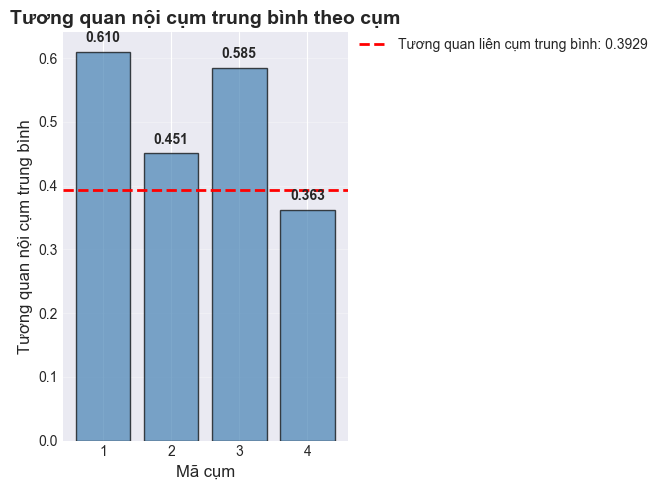

[OK] Saved figure: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\cluster_insight\figures\mean_correlation_by_cluster.png


In [5]:
# Plot and save the mean intra-cluster correlation diagnostic
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    intra_stats_df.index.astype(str),
    intra_stats_df["mean_intra_corr"],
    color="steelblue",
    alpha=0.7,
    edgecolor="black",
)

ax.axhline(
    y=mean_inter,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Tương quan liên cụm trung bình: {mean_inter:.4f}",
)

ax.set_xlabel("Mã cụm", fontsize=12)
ax.set_ylabel("Tương quan nội cụm trung bình", fontsize=12)
ax.set_title("Tương quan nội cụm trung bình theo cụm", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), framealpha=0.95, borderaxespad=0.0)
ax.grid(True, alpha=0.3, axis="y")

for i, (_, val) in enumerate(intra_stats_df["mean_intra_corr"].items()):
    ax.text(i, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout(rect=(0, 0, 0.84, 1))
mean_corr_fig = REPORTS_CLUSTER_INSIGHT_FIG / "mean_correlation_by_cluster.png"
fig.savefig(mean_corr_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"[OK] Saved figure: {mean_corr_fig}")


## Step 4: Ticker-level return and volatility characterization by cluster

The statistics in this section remain **ticker-level**. `mean_ret` is the average daily return of the tickers inside a cluster, and `mean_vol` is the average daily volatility of the tickers inside a cluster. These are descriptive cluster characteristics, not the return or volatility of a cluster portfolio.


In [6]:
print("=" * 60)
print("TICKER-LEVEL RETURN AND VOLATILITY BY CLUSTER")
print("=" * 60)

ret_stats = ret.agg(["mean", "std"]).T
ret_stats.rename(columns={"mean": "mean_ret", "std": "std_ret"}, inplace=True)
ret_stats.index.name = "ticker"

assert ret_stats.shape[0] == expected_number_of_tickers, "ret_stats row count does not match the expected ticker count"
assert ret_stats[["mean_ret", "std_ret"]].isna().sum().sum() == 0, "ret_stats contains NaN values"

print()
print("1. Per-ticker return statistics:")
print(f"   - Shape: {ret_stats.shape}")
print("   - Top 5 tickers by mean_ret:")
print(ret_stats.nlargest(5, "mean_ret"))

clustered_stats = clusters.merge(
    ret_stats, left_on="ticker", right_index=True, how="left"
)

missing_after_merge = int(clustered_stats[["mean_ret", "std_ret"]].isna().sum().sum())
unmatched_tickers = clustered_stats.loc[
    clustered_stats[["mean_ret", "std_ret"]].isna().any(axis=1), "ticker"
].tolist()

assert clustered_stats.shape[0] == expected_number_of_tickers, "clustered_stats row count does not match the expected ticker count"
assert clustered_stats["ticker"].nunique() == expected_number_of_tickers, "clustered_stats has duplicate or missing tickers"
assert missing_after_merge == 0, f"NaN values detected after merging clusters with ret_stats: {unmatched_tickers}"

print()
print("2. Post-merge validation:")
print(f"   - Shape: {clustered_stats.shape}")
print(f"   - Missing values after merge: {missing_after_merge}")
print(clustered_stats.head())

cluster_ret_summary = clustered_stats.groupby("cluster_id").agg(
    n_tickers=("ticker", "count"),
    mean_ret=("mean_ret", "mean"),
    dispersion_mean_ret=("mean_ret", "std"),
    mean_vol=("std_ret", "mean"),
    min_vol=("std_ret", "min"),
    max_vol=("std_ret", "max"),
)

print()
print("3. Cluster-level descriptive summary:")
print(cluster_ret_summary)

high_vol_cluster = int(cluster_ret_summary["mean_vol"].idxmax())
low_vol_cluster = int(cluster_ret_summary["mean_vol"].idxmin())
high_ret_cluster = int(cluster_ret_summary["mean_ret"].idxmax())

print()
print("4. Interpretation notes:")
print("   - mean_ret = average daily return across tickers within each cluster")
print("   - mean_vol = average daily volatility across tickers within each cluster")
print("   - These metrics describe cluster members; they do not represent a cluster portfolio")
print(f"   - Highest mean_vol cluster: Cluster {high_vol_cluster} ({cluster_ret_summary.loc[high_vol_cluster, 'mean_vol']:.6f})")
print(f"   - Lowest mean_vol cluster: Cluster {low_vol_cluster} ({cluster_ret_summary.loc[low_vol_cluster, 'mean_vol']:.6f})")
print(f"   - Highest mean_ret cluster: Cluster {high_ret_cluster} ({cluster_ret_summary.loc[high_ret_cluster, 'mean_ret']:.6f})")

print()
print("[OK] Ticker-level enrichment statistics completed")


TICKER-LEVEL RETURN AND VOLATILITY BY CLUSTER

1. Per-ticker return statistics:
   - Shape: (29, 2)
   - Top 5 tickers by mean_ret:
        mean_ret   std_ret
ticker                    
LPB     0.002006  0.025968
DGC     0.001790  0.025859
SHB     0.001414  0.027292
SSI     0.001114  0.027673
STB     0.001088  0.025317

2. Post-merge validation:
   - Shape: (29, 4)
   - Missing values after merge: 0
  ticker  cluster_id  mean_ret   std_ret
0    ACB           1  0.000903  0.018966
1    BID           1  0.000235  0.022525
2    CTG           1  0.000862  0.022311
3    HDB           1  0.001047  0.022045
4    LPB           1  0.002006  0.025968

3. Cluster-level descriptive summary:
            n_tickers  mean_ret  dispersion_mean_ret  mean_vol   min_vol  \
cluster_id                                                                 
1                  12  0.001005             0.000420  0.022870  0.018966   
2                  10  0.000684             0.000565  0.023590  0.018127   
3       

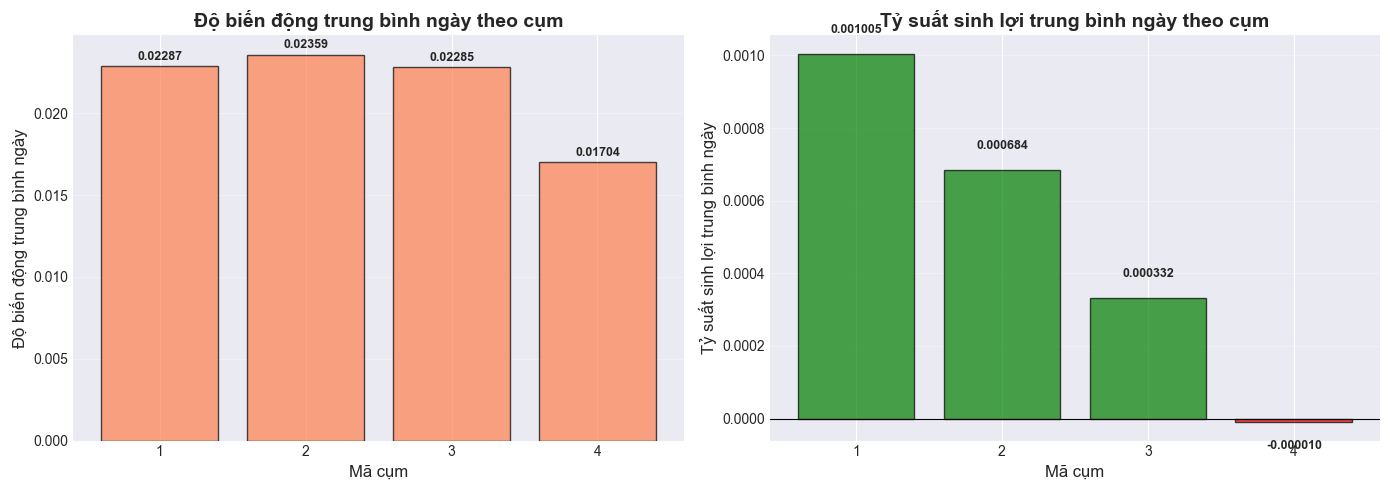

[OK] Saved figure: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\cluster_insight\figures\cluster_mean_return_and_volatility.png


In [7]:
# Plot and save cluster-level mean return and mean volatility diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(
    cluster_ret_summary.index.astype(str),
    cluster_ret_summary["mean_vol"],
    color="coral",
    alpha=0.7,
    edgecolor="black",
)
ax.set_xlabel("Mã cụm", fontsize=12)
ax.set_ylabel("Độ biến động trung bình ngày", fontsize=12)
ax.set_title("Độ biến động trung bình ngày theo cụm", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

for i, (_, val) in enumerate(cluster_ret_summary["mean_vol"].items()):
    ax.text(i, val + 0.0002, f"{val:.5f}", ha="center", va="bottom", fontweight="bold", fontsize=9)

ax = axes[1]
colors = ["green" if x > 0 else "red" for x in cluster_ret_summary["mean_ret"]]
ax.bar(
    cluster_ret_summary.index.astype(str),
    cluster_ret_summary["mean_ret"],
    color=colors,
    alpha=0.7,
    edgecolor="black",
)
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8)
ax.set_xlabel("Mã cụm", fontsize=12)
ax.set_ylabel("Tỷ suất sinh lợi trung bình ngày", fontsize=12)
ax.set_title("Tỷ suất sinh lợi trung bình ngày theo cụm", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

for i, (_, val) in enumerate(cluster_ret_summary["mean_ret"].items()):
    y_offset = 0.00005 if val > 0 else -0.00005
    va = "bottom" if val > 0 else "top"
    ax.text(i, val + y_offset, f"{val:.6f}", ha="center", va=va, fontweight="bold", fontsize=9)

plt.tight_layout()
return_vol_fig = REPORTS_CLUSTER_INSIGHT_FIG / "cluster_mean_return_and_volatility.png"
fig.savefig(return_vol_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"[OK] Saved figure: {return_vol_fig}")


## Step 5: Reordered correlation heatmap for cluster diagnostics

This diagnostic view reorders the correlation matrix by `cluster_id` and then by ticker name. The heatmap is meant to make block structure easier to inspect visually; it does not change the correlation matrix itself.


In [8]:
print("=" * 60)
print("REORDER CORRELATION MATRIX BY CLUSTER")
print("=" * 60)

clusters_sorted = clusters.sort_values(["cluster_id", "ticker"])
ordered_tickers = clusters_sorted["ticker"].tolist()
corr_reordered = corr_matrix.loc[ordered_tickers, ordered_tickers]

print()
print("1. Reordered correlation matrix:")
print(f"   - Shape: {corr_reordered.shape}")
print(f"   - Order: {ordered_tickers}")

print()
print("[OK] Correlation matrix reorder completed")


REORDER CORRELATION MATRIX BY CLUSTER

1. Reordered correlation matrix:
   - Shape: (29, 29)
   - Order: ['ACB', 'BID', 'CTG', 'HDB', 'LPB', 'MBB', 'SHB', 'STB', 'TCB', 'TPB', 'VIB', 'VPB', 'BCM', 'DGC', 'FPT', 'GAS', 'GVR', 'HPG', 'MSN', 'MWG', 'PLX', 'SSI', 'VHM', 'VIC', 'VRE', 'SAB', 'VCB', 'VJC', 'VNM']

[OK] Correlation matrix reorder completed


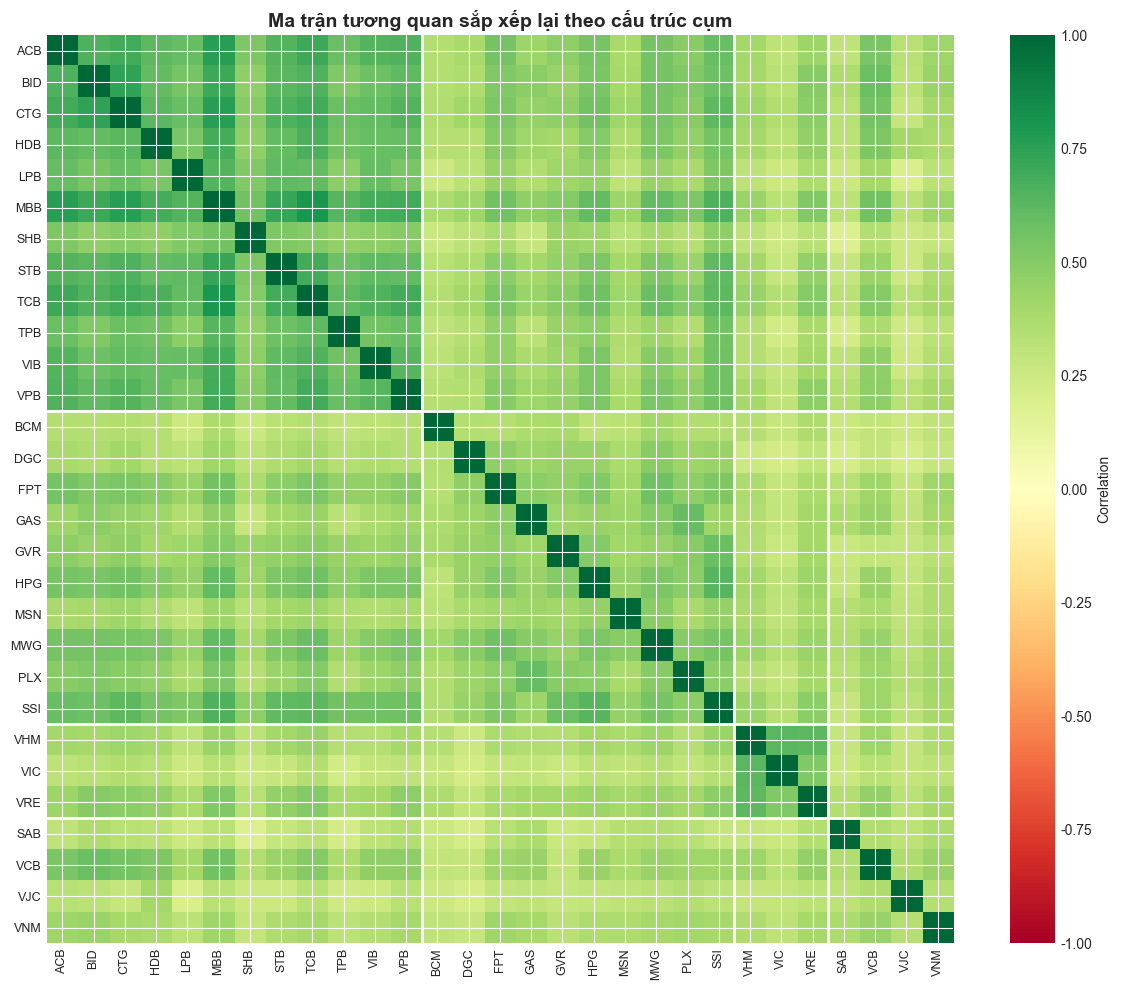

[OK] Saved figure: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\cluster_insight\figures\correlation_heatmap_reordered_by_cluster.png
   - Darker diagonal blocks indicate higher within-cluster correlation.


In [9]:
# Plot and save the reordered correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(corr_reordered.values, aspect="auto", cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Correlation")

ax.set_xticks(range(len(ordered_tickers)))
ax.set_yticks(range(len(ordered_tickers)))
ax.set_xticklabels(ordered_tickers, rotation=90, fontsize=9)
ax.set_yticklabels(ordered_tickers, fontsize=9)
ax.set_title("Ma trận tương quan sắp xếp lại theo cấu trúc cụm", fontsize=14, fontweight="bold")

cluster_boundaries = []
current_cluster = clusters_sorted.iloc[0]["cluster_id"]
for i, row in enumerate(clusters_sorted.itertuples()):
    if row.cluster_id != current_cluster:
        cluster_boundaries.append(i - 0.5)
        current_cluster = row.cluster_id

for boundary in cluster_boundaries:
    ax.axhline(y=boundary, color="white", linewidth=2)
    ax.axvline(x=boundary, color="white", linewidth=2)

plt.tight_layout()
heatmap_fig = REPORTS_CLUSTER_INSIGHT_FIG / "correlation_heatmap_reordered_by_cluster.png"
fig.savefig(heatmap_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"[OK] Saved figure: {heatmap_fig}")
print("   - Darker diagonal blocks indicate higher within-cluster correlation.")


## Step 6: Export the canonical enriched artifact

The export keeps the downstream contract unchanged. The canonical file contains only `ticker`, `cluster_id`, `mean_ret`, and `std_ret`, sorted by `cluster_id` and `ticker`. The file is written only after all validation checks pass.


In [10]:
print("=" * 60)
print("EXPORT CANONICAL ENRICHED ARTIFACT")
print("=" * 60)

ticker_clusters_enriched = clustered_stats[["ticker", "cluster_id", "mean_ret", "std_ret"]].copy()
ticker_clusters_enriched.sort_values(["cluster_id", "ticker"], inplace=True)
ticker_clusters_enriched.reset_index(drop=True, inplace=True)

assert ticker_clusters_enriched.shape[0] == expected_number_of_tickers, "ticker_clusters_enriched row count does not match the expected ticker count"
assert ticker_clusters_enriched[["ticker", "cluster_id", "mean_ret", "std_ret"]].isna().sum().sum() == 0, "ticker_clusters_enriched contains missing values"
assert ticker_clusters_enriched["ticker"].nunique() == expected_number_of_tickers, "ticker_clusters_enriched does not contain a unique row for each ticker"
assert ticker_clusters_enriched["cluster_id"].notna().all(), "ticker_clusters_enriched contains missing cluster_id values"
assert pd.api.types.is_integer_dtype(ticker_clusters_enriched["cluster_id"]), "cluster_id must remain integer-typed"

print()
print("1. Canonical enriched artifact preview:")
print(f"   - Shape: {ticker_clusters_enriched.shape}")
print(f"   - Columns: {list(ticker_clusters_enriched.columns)}")
print(ticker_clusters_enriched.head(10))

enriched_file = DATA_PROCESSED / "ticker_clusters_enriched.csv"
ticker_clusters_enriched.to_csv(enriched_file, index=False)

print()
print(f"2. Exported file: {enriched_file}")
print("   - Contract: ticker, cluster_id, mean_ret, std_ret")
print("   - Ready for notebook 06")

print()
print("[OK] Canonical enriched artifact export completed")


EXPORT CANONICAL ENRICHED ARTIFACT

1. Canonical enriched artifact preview:
   - Shape: (29, 4)
   - Columns: ['ticker', 'cluster_id', 'mean_ret', 'std_ret']
  ticker  cluster_id  mean_ret   std_ret
0    ACB           1  0.000903  0.018966
1    BID           1  0.000235  0.022525
2    CTG           1  0.000862  0.022311
3    HDB           1  0.001047  0.022045
4    LPB           1  0.002006  0.025968
5    MBB           1  0.000926  0.020798
6    SHB           1  0.001414  0.027292
7    STB           1  0.001088  0.025317
8    TCB           1  0.000766  0.022232
9    TPB           1  0.000736  0.021932

2. Exported file: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\data\processed\ticker_clusters_enriched.csv
   - Contract: ticker, cluster_id, mean_ret, std_ret
   - Ready for notebook 06

[OK] Canonical enriched artifact export completed


## Final summary and downstream handoff

This notebook finishes the diagnostic and metadata enrichment step for clustering. The next notebook is `06_markowitz_static.ipynb`, which uses `mean_ret` as `mu` and uses `cluster_id` to apply cluster caps.


In [11]:
print("=" * 80)
print("FINAL SUMMARY - CLUSTER DIAGNOSTIC AND METADATA ENRICHMENT")
print("=" * 80)

print()
print("1. Cluster structure:")
print(f"   - Total number of clusters: {len(cluster_counts)}")
print(f"   - Ticker count by cluster: {dict(cluster_counts)}")
print(f"   - min_cluster_size: {min_cluster_size}")
print(f"   - max_cluster_size: {max_cluster_size}")

print()
print("2. Correlation diagnostic:")
print(f"   - mean_intra_corr: {mean_intra:.4f}")
print(f"   - mean_inter_corr: {mean_inter:.4f}")
print(f"   - intra/inter ratio: {corr_ratio:.2f}x")
print(f"   - note: {corr_quality_note}")

print()
print("3. Enriched artifact export:")
print(f"   - Exported file: {enriched_file}")
print("   - Schema: ticker, cluster_id, mean_ret, std_ret")

print()
print("4. Figure outputs:")
print(f"   - {mean_corr_fig}")
print(f"   - {return_vol_fig}")
print(f"   - {heatmap_fig}")

print()
print("5. Downstream handoff:")
print("   - Next notebook: 06_markowitz_static.ipynb")
print("   - Notebook 06 uses mean_ret as mu")
print("   - Notebook 06 uses cluster_id to apply cluster caps")
print("   - The clustering role remains cluster constraints / diversification constraints based on clusters")

print()
print("=" * 80)
print("NOTEBOOK 05 COMPLETED")
print("=" * 80)


FINAL SUMMARY - CLUSTER DIAGNOSTIC AND METADATA ENRICHMENT

1. Cluster structure:
   - Total number of clusters: 4
   - Ticker count by cluster: {1: 12, 2: 10, 3: 3, 4: 4}
   - min_cluster_size: 3
   - max_cluster_size: 12

2. Correlation diagnostic:
   - mean_intra_corr: 0.5372
   - mean_inter_corr: 0.3929
   - intra/inter ratio: 1.37x
   - note: Mean intra-cluster correlation is higher than mean inter-cluster correlation, so the cluster structure shows meaningful internal correlation separation.

3. Enriched artifact export:
   - Exported file: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\data\processed\ticker_clusters_enriched.csv
   - Schema: ticker, cluster_id, mean_ret, std_ret

4. Figure outputs:
   - D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\cluster_insight\figures\mean_correlation_by_cluster.png
   - D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\report